### 1) Project Overview

### 2) Business Problem

### 3) Objectives

### 4) Dataset Information

### 5) Technologies Used

### 6) Project Workflow

#### 1) Import Libraries

In [1]:
# Basic
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Model Selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#### 2) Data Collection

In [2]:
del_time = pd.read_csv('C:/Users/Admin/Documents/GitHub/delivery-time-prediction-linear-regression/Dataset/Food Delivery Times.csv')
del_time

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


#### 3) Data Understanding

In [3]:
del_time.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [4]:
del_time.tail()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55
999,103,6.63,Foggy,Low,Night,Scooter,24,3.0,58


In [5]:
del_time.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

#### 4) Explortary Data Analysis (EDA)

#### 1) Dataset Shape

In [6]:
del_time.shape

(1000, 9)

#### 2) Data Type

In [8]:
del_time.dtypes

Order_ID                    int64
Distance_km               float64
Weather                    object
Traffic_Level              object
Time_of_Day                object
Vehicle_Type               object
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Delivery_Time_min           int64
dtype: object

#### 3) Missing Values

In [9]:
del_time.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

##### Observation

#### 4) Duplicate Values

In [11]:
del_time.duplicated().sum()

np.int64(0)

#### 5) Statistical Summary

In [12]:
del_time.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


#### 6) Correlation Analysis

In [13]:
del_time.corr(numeric_only=True)

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
Order_ID,1.000000,-0.024483,-0.035100,0.013152,-0.036650
Distance_km,-0.024483,1.000000,-0.009037,-0.007842,0.780998
Preparation_Time_min,-0.035100,-0.009037,1.000000,-0.030830,0.307350
Courier_Experience_yrs,0.013152,-0.007842,-0.030830,1.000000,-0.090433
Delivery_Time_min,-0.036650,0.780998,0.307350,-0.090433,1.000000


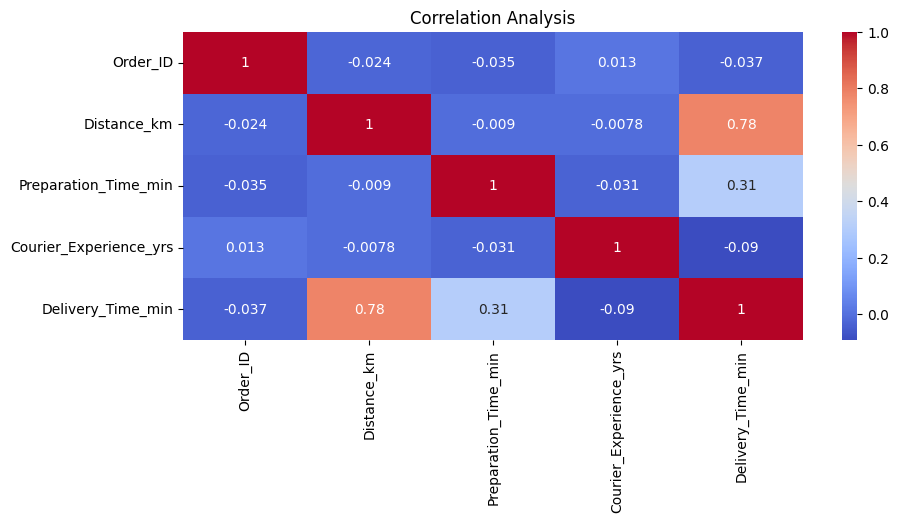

In [14]:
# Visulation 

plt.figure(figsize=(10,4))

sns.heatmap(del_time.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title('Correlation Analysis')

plt.show()

#### 7) Class Distribution

In [15]:
del_time.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

In [18]:
del_time['Order_ID'].unique().sum()

np.int64(500500)

In [20]:
del_time['Distance_km'].unique().sum()

np.float64(7896.21)

In [21]:
del_time['Weather'].value_counts()

Weather
Clear    470
Rainy    204
Foggy    103
Snowy     97
Windy     96
Name: count, dtype: int64

In [22]:
del_time['Traffic_Level'].value_counts()

Traffic_Level
Medium    390
Low       383
High      197
Name: count, dtype: int64

In [23]:
del_time['Time_of_Day'].value_counts()

Time_of_Day
Morning      308
Evening      293
Afternoon    284
Night         85
Name: count, dtype: int64

In [24]:
del_time['Vehicle_Type'].value_counts()

Vehicle_Type
Bike       503
Scooter    302
Car        195
Name: count, dtype: int64

In [26]:
del_time['Preparation_Time_min'].unique().sum()

np.int64(425)

In [27]:
del_time['Courier_Experience_yrs'].value_counts()

Courier_Experience_yrs
6.0    109
9.0    108
1.0    107
8.0    101
2.0     99
4.0     94
0.0     91
7.0     91
5.0     90
3.0     80
Name: count, dtype: int64

#### 8) Outliers Detection

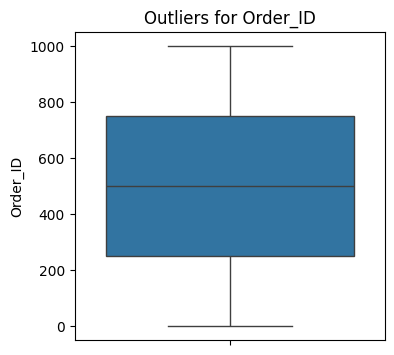

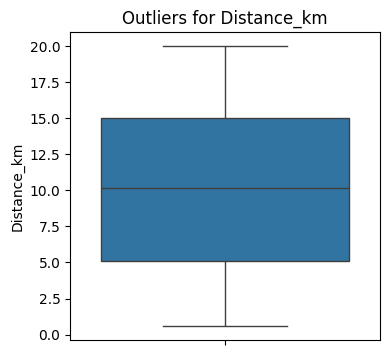

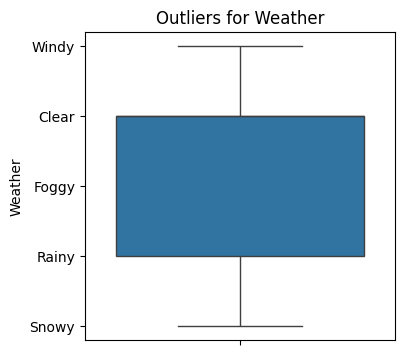

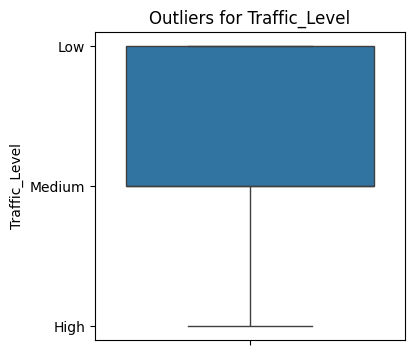

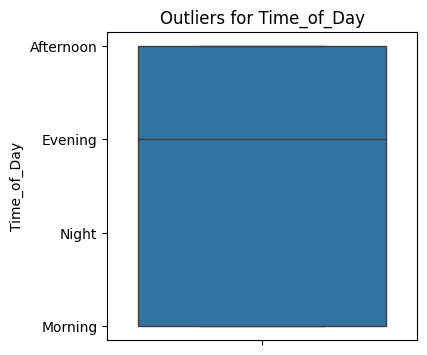

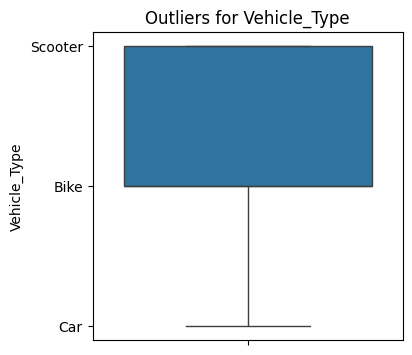

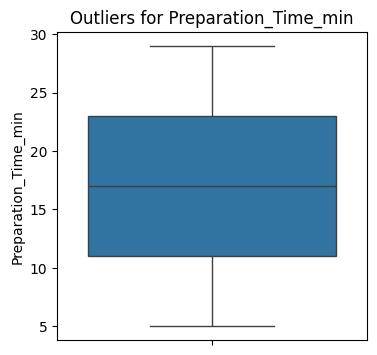

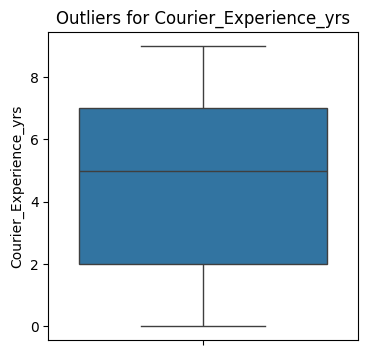

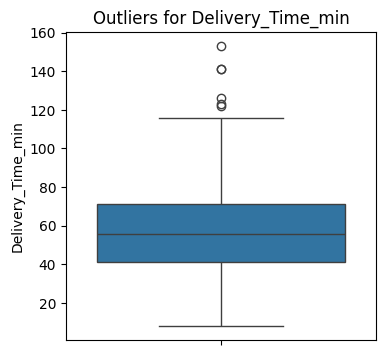

In [33]:
columns = del_time.columns

for out_col in columns:
    plt.figure(figsize=(4,4))
    sns.boxplot(data=del_time[out_col])
    plt.title(f'Outliers for {out_col}')
    plt.show()


##### Observation

#### 9) Feature Distribution

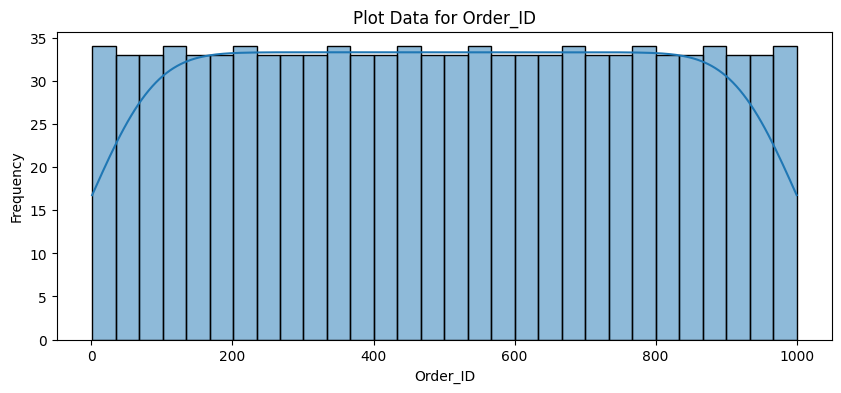

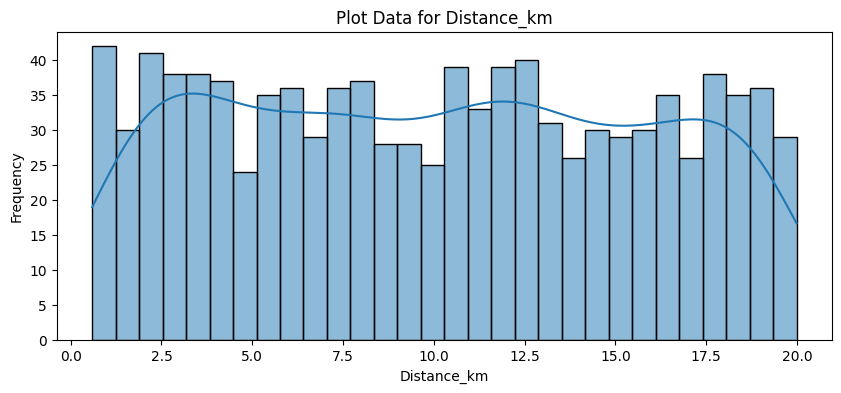

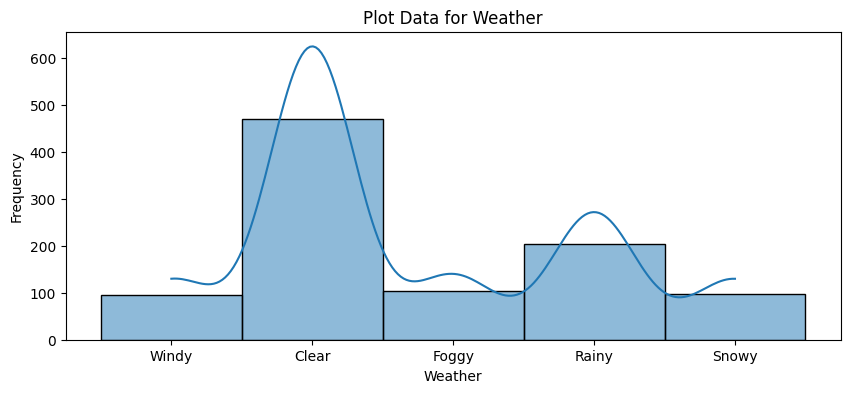

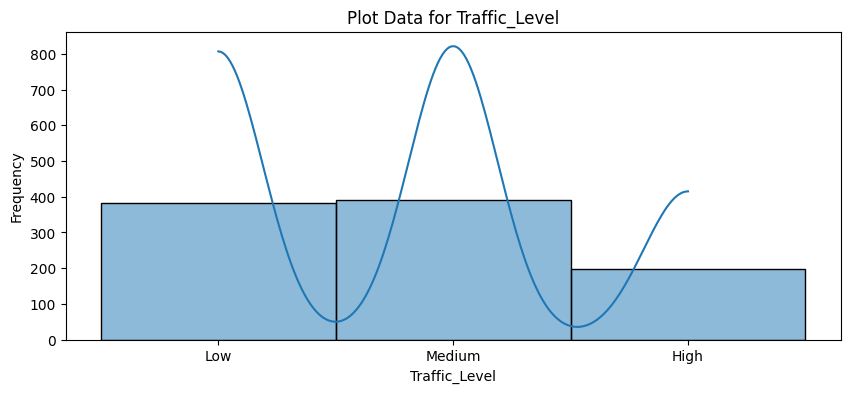

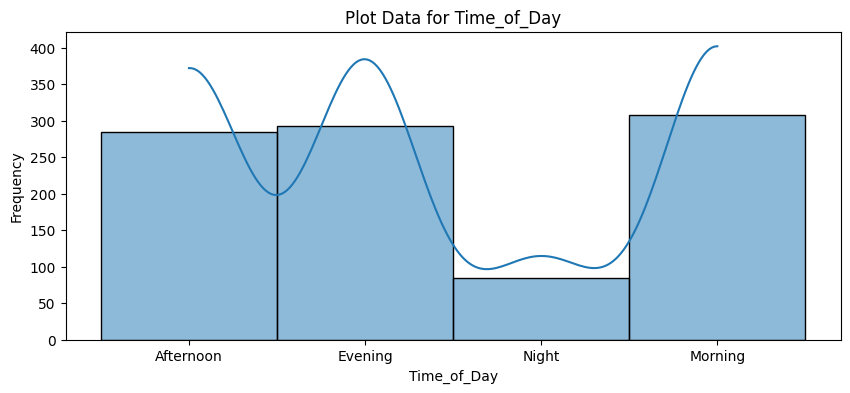

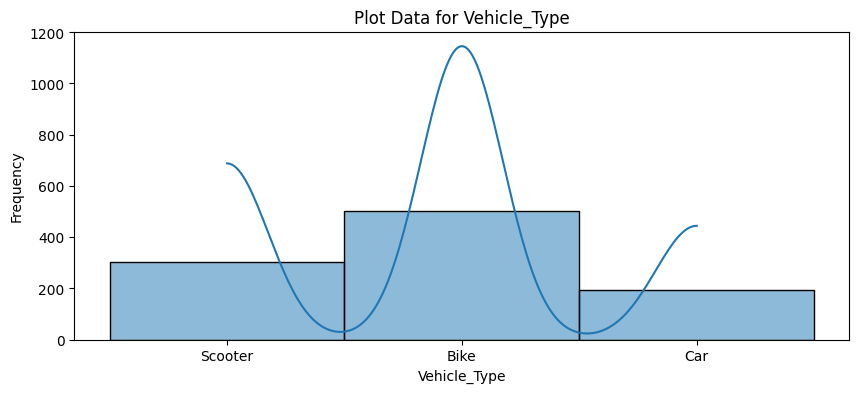

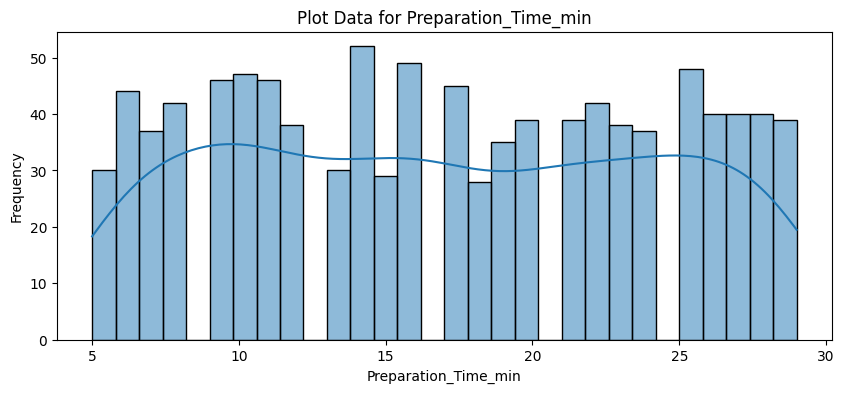

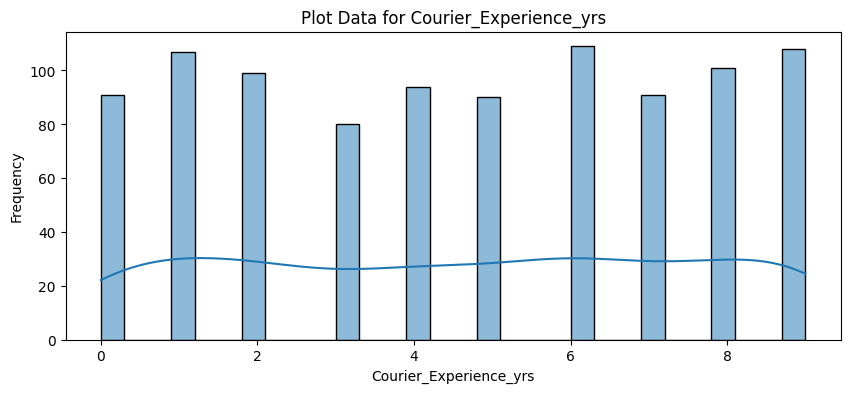

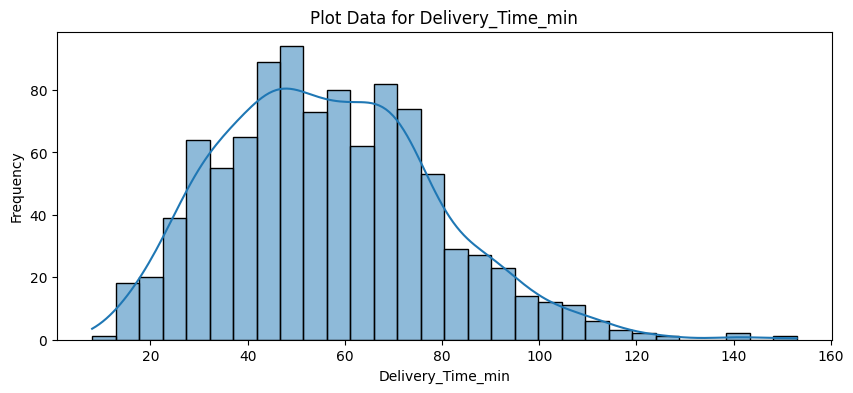

In [35]:
columns = del_time.columns

for a in columns:
    plt.figure(figsize=(10,4))

    sns.histplot(del_time[a], bins=30, kde=True)

    plt.title(f'Plot Data for {a}')
    plt.xlabel(a)
    plt.ylabel('Frequency')
    plt.show()

##### Observation

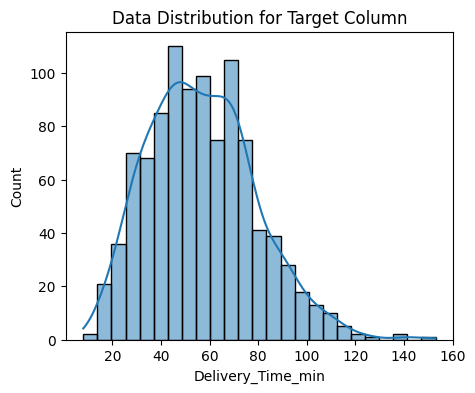

In [39]:
target_col = del_time['Delivery_Time_min']

plt.figure(figsize=(5,4))

sns.histplot(target_col, kde=True)

plt.title('Data Distribution for Target Column')

plt.show()

#### Bi-Variant 

In [40]:
del_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [ ]:
# Distance km vs Delivery Time min
